# Lab: Fourier Neural Operator on Darcy flow

This notebook is inspired by the *Training on Darcy Flow* notebook of the **NeuralOperator bootcamp**:
configuration -> Darcy data -> baseline (U‑Net) -> main model (FNO/TFNO) -> training with `Trainer` -> 32×32 / 64×64 test -> ablations.


If a GPU is available, simply increase `n_train` and `n_epochs`.

---


In [1]:
# --- NeuralOperator dependencies ---
# The package is installed as "neuraloperator" but imported as "neuralop".
# On Colab, run this cell.

import sys, importlib, pkgutil

print("Python:", sys.version)
if sys.version_info < (3, 9):
    raise RuntimeError("NeuralOperator requires Python >= 3.9 (see PyPI). Use Colab or update your environment.")

if pkgutil.find_loader("neuralop") is None:
    print("Installing neuraloperator (PyPI)...")
    !pip -q install -U neuraloperator
    importlib.invalidate_caches()

import neuralop
print("neuralop import OK | version:", getattr(neuralop, "__version__", "unknown"))


Python: 3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]


/tmp/ipykernel_480/2059069319.py:11: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if pkgutil.find_loader("neuralop") is None:


neuralop import OK | version: 2.0.0


In [2]:
# Installation (Colab/VM). On an already configured machine, this can be commented out.
# !pip -q install neuraloperator

import os
import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

torch.manual_seed(0)
np.random.seed(0)


Device: cpu


In [3]:
# Hide benign warnings (x ignored by the losses, pin_memory without a GPU)
import warnings
warnings.filterwarnings("ignore", message=".*unexpected keyword arguments.*")
warnings.filterwarnings("ignore", message=".*pin_memory.*")


## 0. Background: Darcy flow (porous media)

We model a flow in a **porous medium** (soil, rock, filter).

- $u(x,y)$: **pressure** (or hydraulic head)
- $a(x,y)$: **permeability / conductivity** (varies in space)
- $f(x,y)$: source term (injection/extraction), often fixed in the benchmark

### Equations
**Darcy's law** (flux/velocity):
$$
\mathbf{v}(x,y) = -a(x,y)\,\nabla u(x,y)
$$

**Mass conservation** (incompressible):
$$
\nabla \cdot \mathbf{v}(x,y) = f(x,y)
$$

Hence the PDE:
$$
-\nabla \cdot (a(x,y)\nabla u(x,y)) = f(x,y)
$$
typically with a **Dirichlet** condition $u=0$ on the boundary of the square.

### What we learn (operator learning)
We learn a map:
$$
\mathcal{G}: a(\cdot)\mapsto u(\cdot)
$$
i.e. **field -> field**. This is closer to "solving a PDE by learning" than to classical regression.

---


## 0bis. Background: what is a Fourier Neural Operator (FNO)?

An FNO also learns a **field -> field** map, but with one key idea:

> Instead of applying only local convolutions (CNN), it learns transformations in the **Fourier domain**.

### Intuition (simple version)
For a tensor $x(x,y)$ (several channels):
1. **2D FFT**: $\hat x = \mathcal{F}(x)$
2. Keep only the **low frequencies** (the "modes"): truncate to `n_modes=(m1,m2)`
3. Apply a learned linear transformation to these modes (complex weights): $\hat y_{k} = W_k \hat x_{k}$
4. **iFFT**: $y = \mathcal{F}^{-1}(\hat y)$

A pointwise branch (1×1 conv / per-pixel MLP) and non-linearities are then added, and several blocks are stacked.

### Key hyperparameters
- `n_modes=(m1,m2)`: how many low frequencies are kept.
  - small -> output too smooth (loss of detail)
  - large -> more detail, but more expensive (and sometimes less stable)
- `hidden_channels`: width (number of internal channels)
- `n_layers`: depth (number of FNO blocks)

### TFNO (Tensorized FNO)
`TFNO` is a factorized variant (Tucker, etc.) that aims to **reduce the cost** when the size grows (modes / channels).
In this lab we use TFNO when possible, FNO otherwise.

### Why "generalize across resolutions"?
In many settings, one trains on 32×32 and tests on 64×64 ("zero-shot super-resolution").
The idea is that the FNO learns a "spectral" transformation that remains valid on finer grids.

---


## 1. Configuration (bootcamp style)

**CPU-friendly** default values.

Rule of thumb:
- If it does not run on CPU: lower `n_train`, `n_epochs`, then `hidden_channels`, then `n_modes`.
- To use a GPU (device="cuda"): first increase `n_train`, then `n_epochs`, then `hidden_channels`.

Important parameters:
- `training_loss`: `"l2"` (amplitude) or `"h1"` (amplitude + fine structure)
- `n_modes`: spectral detail that can be captured
- `hidden_channels`: capacity
- `n_layers`: depth

---


In [4]:
config = {
    "data": {
        "n_train": 256,          # CPU: 128–512 ; GPU: 2000+
        "batch_size": 16,
        # Note: with neuralop 2.x, load_darcy_flow_small ALWAYS trains at 16×16.
        # We therefore add 16 to the test resolutions ("same resolution" reference);
        # 32 and 64 are then two zero-shot tests (x2 and x4).
        "n_tests": [64, 64, 64],
        "test_resolutions": [16, 32, 64],
        "test_batch_sizes": [16, 16, 8],
        "train_resolution": 16,
    },
    "unet": {
        "base_channels": 16,     # CPU: 8–16 ; GPU: 32–64
        "depth": 4,
    },
    "fno": {
        "n_modes": (12, 12),     # e.g. (8,8), (16,16), (24,24)
        "hidden_channels": 16,   # CPU: 16 ; GPU: 64+
        "n_layers": 4,
        "factorization": "tucker",   # set to None for a "full" FNO
        "implementation": "factorized",
        "rank": 0.2,
        "projection_channels": 128,
    },
    "opt": {
        "n_epochs": 10,          # CPU: 5–20 ; GPU: 30–80
        "learning_rate": 5e-3,
        "weight_decay": 1e-4,
        "scheduler": "CosineAnnealingLR",
        "scheduler_T_max": 50,
        "step_size": 20,
        "gamma": 0.5,
        "training_loss": "h1",   # "l2" or "h1"
    }
}

## 2. Load the Darcy dataset (NeuralOperator)

The loader returns:
- `train_loader`
- `test_loaders` (often 32×32 and 64×64)
- `data_processor` (normalization + encodings)


In [5]:
# Compatibility: recent vs older API
load_fn = None
load_api = None

try:
    from neuralop.data.datasets import load_darcy_flow_small as load_fn
    load_api = "load_darcy_flow_small"
except Exception:
    try:
        from neuralop.datasets import load_darcy_pt as load_fn
        load_api = "load_darcy_pt"
    except Exception as e:
        raise RuntimeError(
            "Could not import a Darcy loader from NeuralOperator. "
            "Check the neuraloperator installation."
        ) from e

print("Using loader:", load_api)

def load_darcy(n_train, test_resolutions, n_tests, test_batch_sizes, batch_size):
    if load_api == "load_darcy_flow_small":
        return load_fn(
            n_train=n_train, batch_size=batch_size, n_tests=n_tests,
            test_resolutions=test_resolutions, test_batch_sizes=test_batch_sizes,
        )
    # Old API: requires local .pt files
    return load_fn(
        "./data/darcy_flow", train_resolution=config["data"]["train_resolution"],
        n_train=n_train, batch_size=batch_size, test_resolutions=test_resolutions,
        n_tests=n_tests, test_batch_sizes=test_batch_sizes,
        positional_encoding=True, encode_input=True, encode_output=False,
    )

dcfg = config["data"]
try:
    train_loader, test_loaders, data_processor = load_darcy(
        dcfg["n_train"], dcfg["test_resolutions"], dcfg["n_tests"], dcfg["test_batch_sizes"], dcfg["batch_size"])
except Exception as e:
    # Fallback if a resolution cannot be downloaded (e.g. no access to Zenodo):
    # keep the bundled / already available resolutions (16 and 32).
    print("Download failed for", dcfg["test_resolutions"], "->", repr(e)[:120])
    keep = [i for i, r in enumerate(dcfg["test_resolutions"]) if r in (16, 32)]
    for k in ("test_resolutions", "n_tests", "test_batch_sizes"):
        dcfg[k] = [dcfg[k][i] for i in keep]
    print("Falling back to test resolutions:", dcfg["test_resolutions"])
    train_loader, test_loaders, data_processor = load_darcy(
        dcfg["n_train"], dcfg["test_resolutions"], dcfg["n_tests"], dcfg["test_batch_sizes"], dcfg["batch_size"])

sample = next(iter(train_loader))
if isinstance(sample, (list, tuple)):
    x, y = sample
else:
    x, y = sample["x"], sample["y"]

print("Batch x:", x.shape, "Batch y:", y.shape)
in_channels = x.shape[1]
print("Inferred in_channels:", in_channels)
TEST_RES = list(test_loaders.keys()) if isinstance(test_loaders, dict) else dcfg["test_resolutions"]
print("Training resolution:", x.shape[-1], "| test resolutions:", TEST_RES,
      "| sizes:", {r: len(l.dataset) for r, l in zip(TEST_RES, test_loaders.values())})

Using loader: load_darcy_flow_small
Download failed for [16, 32, 64] -> AssertionError('Error: request failed with status code 403')
Falling back to test resolutions: [16, 32]
Loading test db for resolution 16 with 64 samples 
Loading test db for resolution 32 with 64 samples 


Batch x: torch.Size([16, 1, 16, 16]) Batch y: torch.Size([16, 1, 16, 16])
Inferred in_channels: 1
Training resolution: 16 | test resolutions: [16, 32] | sizes: {16: 50, 32: 50}


### Important note on the training resolution

The printed batch is **16×16**: with `neuraloperator` 2.x, `load_darcy_flow_small` hard-codes `train_resolution=16` (the `train_resolution` parameter of the config is only used by the old API). Consequences:

* the 16×16 test is the only test at the **same resolution** as training;
* the 32×32 and 64×64 tests are **both zero-shot** (factor 2 and factor 4).

This is why `16` was added to the test resolutions. Another useful detail for the next cell: the input `a` is a **binary** field (0/1, the two phases of the porous medium), and the grid is a subsampling of a fine grid that does not land exactly on the right and top boundaries. Only the first row and first column lie on the Dirichlet boundary ($u\approx 0$), which explains why the mean of $|u|$ over the four borders is not zero.

**Saved run:** resolution 64 could not be downloaded from my environment (no access to Zenodo), so the cell automatically fell back to `[16, 32]`. On Colab, 64 loads normally.

## 3. Visualizations: fields and flux

We visualize $a(x,y)$, $u(x,y)$ and the flux $\mathbf{v}=-a \nabla u$.


u border mean| |: 0.1940363645553589  max|u|: 0.5274391174316406


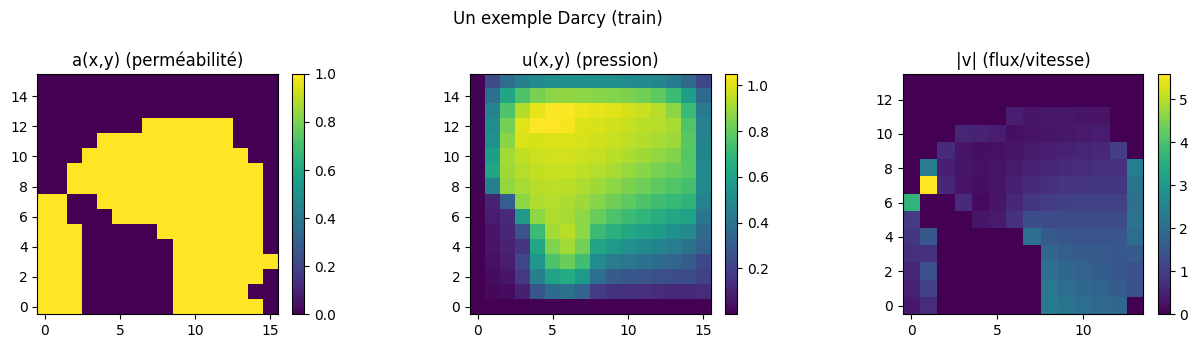

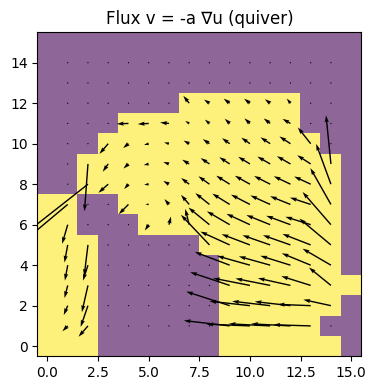

In [6]:
def show_darcy_example(x, y, title=""):
    x0 = x[0].detach().cpu()
    u0 = y[0, 0].detach().cpu()

    a = x0[0]  # assumption: channel 0 = permeability

    # Check the border (often u≈0)
    border = torch.cat([u0[0, :], u0[-1, :], u0[:, 0], u0[:, -1]])
    print("u border mean| |:", border.abs().mean().item(), " max|u|:", border.abs().max().item())

    fig, axs = plt.subplots(1, 3, figsize=(13, 3.5))
    axs[0].set_title("a(x,y) (permeability)")
    im0 = axs[0].imshow(a, origin="lower"); plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

    axs[1].set_title("u(x,y) (pressure)")
    im1 = axs[1].imshow(u0, origin="lower"); plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

    H, W = u0.shape
    dx = 1.0 / (H - 1)
    dy = 1.0 / (W - 1)

    du_dx = (u0[2:, 1:-1] - u0[:-2, 1:-1]) / (2 * dx)
    du_dy = (u0[1:-1, 2:] - u0[1:-1, :-2]) / (2 * dy)
    a_c = a[1:-1, 1:-1]

    vx = -a_c * du_dx
    vy = -a_c * du_dy
    speed = torch.sqrt(vx**2 + vy**2)

    axs[2].set_title("|v| (flux/velocity)")
    im2 = axs[2].imshow(speed, origin="lower"); plt.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

    # Quiver
    step = max(1, H // 16)
    Y, X = torch.meshgrid(torch.arange(1, H-1), torch.arange(1, W-1), indexing="ij")
    Xq = X[::step, ::step].numpy()
    Yq = Y[::step, ::step].numpy()
    vx_q = vx[::step, ::step].numpy()
    vy_q = vy[::step, ::step].numpy()

    plt.figure(figsize=(4, 4))
    plt.title("Flux v = -a ∇u (quiver)")
    plt.imshow(a, origin="lower", alpha=0.6)
    plt.quiver(Xq, Yq, vx_q, vy_q, color="k", angles="xy", scale_units="xy", scale=1.0)
    plt.tight_layout()
    plt.show()

show_darcy_example(x, y, title="A Darcy example (train)")


## 4. Losses and metrics: what do they measure?

NeuralOperator provides losses suited to operator learning (fields).

### Relative L2 (`LpLoss(d=2,p=2)`)
It measures the global amplitude error:
$$
\text{relL2}(\hat u,u)=\frac{\|\hat u-u\|_2}{\|u\|_2}
$$
Intuition: "does the prediction have the right **scale** and the right **overall shape**?"

### H1 (`H1Loss(d=2)`)
The $H^1$ norm compares **the function** and also its **derivatives**:
$$
\|\hat u-u\|_{H^1}^2 \approx \|\hat u-u\|_2^2 + \|\nabla \hat u-\nabla u\|_2^2
$$
Intuition: "does the prediction also respect the **fine structure** (slopes, gradients)?"

In Darcy flow, the gradients $\nabla u$ are directly linked to the **flux**:
$$
\mathbf{v}=-a\nabla u
$$
so an $H^1$ loss can improve the "physical" quality of the field (more realistic gradients).

### Which one for training?
- Training with **L2**: simpler, often more stable, but can be smoother.
- Training with **H1**: enforces the fine structure, sometimes harder but more faithful (depending on the case).

> Note: a warning such as "H1Loss received unexpected keyword argument 'x'" comes from the way `Trainer` passes the batch (`x`, `y`) to the loss. `x` is simply ignored; it is harmless.

---


In [7]:
try:
    from neuralop import LpLoss, H1Loss
except Exception:
    from neuralop.losses import LpLoss, H1Loss

l2loss = LpLoss(d=2, p=2)
h1loss = H1Loss(d=2)

if config["opt"]["training_loss"] == "l2":
    train_loss = l2loss
elif config["opt"]["training_loss"] == "h1":
    train_loss = h1loss
else:
    raise ValueError('training_loss must be "l2" or "h1"')

eval_losses = {"l2": l2loss, "h1": h1loss}
print("Training loss:", config["opt"]["training_loss"])

# Small helper for the ablations
def set_training_loss(name: str):
    """Updates config['opt']['training_loss'] and the global variable train_loss."""
    global train_loss
    name = name.lower()
    if name == "l2":
        train_loss = l2loss
        config["opt"]["training_loss"] = "l2"
    elif name == "h1":
        train_loss = h1loss
        config["opt"]["training_loss"] = "h1"
    else:
        raise ValueError('name must be "l2" or "h1"')
    print("Training loss set to:", config["opt"]["training_loss"])


Training loss: h1


## 5. Training pipeline (Trainer)

We wrap the `Trainer` logic to train the U-Net, then the (T)FNO.


In [8]:
# Trainer (the API varies across versions)
try:
    from neuralop.training import Trainer as TrainerCls
except Exception:
    from neuralop import Trainer as TrainerCls

def make_optimizer_and_scheduler(model, opt_cfg):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=opt_cfg["learning_rate"],
        weight_decay=opt_cfg["weight_decay"],
    )

    if opt_cfg["scheduler"] == "CosineAnnealingLR":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=opt_cfg["scheduler_T_max"])
    elif opt_cfg["scheduler"] == "StepLR":
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=opt_cfg["step_size"], gamma=opt_cfg["gamma"])
    elif opt_cfg["scheduler"] == "ReduceLROnPlateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=opt_cfg["gamma"], patience=5, mode="min")
    else:
        raise ValueError(f'Unknown scheduler: {opt_cfg["scheduler"]}')
    return optimizer, scheduler


def train_with_trainer(model, name):
    model = model.to(device)
    optimizer, scheduler = make_optimizer_and_scheduler(model, config["opt"])

    # Build the Trainer (recent API preferred)
    try:
        trainer = TrainerCls(model=model, n_epochs=config["opt"]["n_epochs"], device=device, verbose=True, data_processor=data_processor)
        trainer_api = "new"
    except TypeError:
        trainer = TrainerCls(model, n_epochs=config["opt"]["n_epochs"], device=device, verbose=True)
        trainer_api = "old"

    print(f"\n=== Training {name} (Trainer API: {trainer_api}) ===")

    if trainer_api == "new":
        trainer.train(
            train_loader=train_loader,
            test_loaders=test_loaders,
            optimizer=optimizer,
            scheduler=scheduler,
            regularizer=False,
            training_loss=train_loss,
            eval_losses=eval_losses,
        )
    else:
        # legacy fallback
        try:
            trainer.train(
                train_loader, test_loaders,
                data_processor,
                model,
                optimizer,
                scheduler,
                regularizer=False,
                training_loss=train_loss,
                eval_losses=eval_losses,
            )
        except TypeError:
            trainer.train(
                train_loader, test_loaders,
                optimizer=optimizer,
                scheduler=scheduler,
                regularizer=False,
                training_loss=train_loss,
                eval_losses=eval_losses,
            )

    return model


@torch.no_grad()
def get_loader(test_loaders, idx=0):
    if isinstance(test_loaders, dict):
        keys = list(test_loaders.keys())
        return test_loaders[keys[idx]]
    if isinstance(test_loaders, (list, tuple)):
        return test_loaders[idx]
    return test_loaders


@torch.no_grad()
def show_batch_predictions(model, loader, title=""):
    model.eval()
    batch = next(iter(loader))

    if isinstance(batch, (list, tuple)):
        xb, yb = batch
        xb = xb.to(device); yb = yb.to(device)
        pred = model(xb)
    else:
        batch = {k: v.to(device) for k, v in batch.items()}
        try:
            pred = model(**batch)
            xb, yb = batch["x"], batch["y"]
        except TypeError:
            xb, yb = batch["x"], batch["y"]
            pred = model(xb)

    x0 = xb[0].detach().cpu()
    y0 = yb[0].detach().cpu()
    p0 = pred[0].detach().cpu()

    a = x0[0]
    u = y0[0] if y0.ndim == 3 else y0.squeeze(0)
    uhat = p0[0] if p0.ndim == 3 else p0.squeeze(0)
    err = uhat - u

    fig, axs = plt.subplots(1, 4, figsize=(14, 3))
    axs[0].set_title("a (input)"); im0 = axs[0].imshow(a, origin="lower"); plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
    axs[1].set_title("u (true)"); im1 = axs[1].imshow(u, origin="lower"); plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
    axs[2].set_title("u_hat (pred)"); im2 = axs[2].imshow(uhat, origin="lower"); plt.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)
    axs[3].set_title("error"); im3 = axs[3].imshow(err, origin="lower"); plt.colorbar(im3, ax=axs[3], fraction=0.046, pad=0.04)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def evaluate_quick(model, loader):
    model.eval()
    l2s, h1s, n = 0.0, 0.0, 0
    for batch in loader:
        if isinstance(batch, (list, tuple)):
            xb, yb = batch
            xb = xb.to(device); yb = yb.to(device)
            pred = model(xb)
        else:
            batch = {k: v.to(device) for k, v in batch.items()}
            try:
                pred = model(**batch)
                yb = batch["y"]
            except TypeError:
                pred = model(batch["x"])
                yb = batch["y"]

        l2s += eval_losses["l2"](pred, yb).item()
        h1s += eval_losses["h1"](pred, yb).item()
        n += 1
    return {"l2": l2s / max(n, 1), "h1": h1s / max(n, 1)}


### Fixing the evaluation helpers

The original versions of `evaluate_quick` / `show_batch_predictions` called the model **without** the `data_processor`. But here `encode_output=True`: the model predicts a **normalized** output, which the `Trainer` de-normalizes before computing the metric. Without this step, a normalized output is compared to the raw ground truth. Moreover, the `neuralop` losses use `reduction="sum"`: the per-batch sum was averaged over the number of batches, not over the number of samples. Hence values like `l2=29`, inconsistent with the `Trainer` (~0.7).

The versions below go through `data_processor.preprocess/postprocess` (in `eval` mode) and return a **mean relative error per sample**, directly comparable to the `Trainer` logs.

In [9]:
@torch.no_grad()
def predict(model, batch, dp=None):
    """Prediction in physical space (same path as Trainer.evaluate)."""
    dp = data_processor if dp is None else dp
    model.eval(); dp.eval()
    batch = {k: v.clone() for k, v in batch.items()}
    sample = dp.preprocess(batch)
    out = model(**sample)
    out, sample = dp.postprocess(out, sample)
    return sample["x"], sample["y"], out


@torch.no_grad()
def evaluate_quick(model, loader, dp=None):
    """Mean relative L2 and H1 errors per sample."""
    l2s, h1s, n = 0.0, 0.0, 0
    for batch in loader:
        _, yb, pred = predict(model, batch, dp)
        l2s += eval_losses["l2"](pred, yb).item()   # reduction='sum' over the batch
        h1s += eval_losses["h1"](pred, yb).item()
        n += yb.shape[0]
    return {"l2": l2s / n, "h1": h1s / n}


@torch.no_grad()
def show_batch_predictions(model, loader, title="", idx=0):
    xb, yb, pred = predict(model, next(iter(loader)))
    a, u, uhat = xb[idx, 0].cpu(), yb[idx, 0].cpu(), pred[idx, 0].cpu()
    err = uhat - u
    fig, axs = plt.subplots(1, 4, figsize=(14, 3))
    for ax, img, t in zip(axs, [a, u, uhat, err], ["a (input)", "u (true)", "u_hat (pred)", "error"]):
        im = ax.imshow(img, origin="lower", cmap="RdBu_r" if t == "error" else None)
        ax.set_title(t); plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.suptitle(title); plt.tight_layout(); plt.show()


def count_params(model):
    return sum(p.numel() for p in model.parameters())

## 6. Baseline: U‑Net (field -> field CNN)

Before moving to Fourier operators, we want a **strong**, standard baseline for "image->image" tasks.

### Why a U‑Net?
- It is a widely used CNN architecture (segmentation / denoising / super-resolution).
- It combines:
  - an **encoder** (downsampling) that aggregates context,
  - a **decoder** (upsampling),
  - **skip connections** that re-inject high-resolution details.

### Expected behavior
- Very good at the **same resolution** as training.
- Not necessarily "naturally" robust when the resolution changes (32->64), even if it sometimes works.

In this lab, the U‑Net is used to ask:
> Does the (T)FNO bring anything beyond a modern CNN?

---


In [10]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)

class Encoder(nn.Module):
    def __init__(self, in_channels, base=16, depth=4):
        super().__init__()
        self.depth = depth

        self.stem = DoubleConv(in_channels, base)
        self.pools = nn.ModuleList()
        self.blocks = nn.ModuleList()

        ch = base
        for _ in range(depth):
            self.pools.append(nn.MaxPool2d(2))
            self.blocks.append(DoubleConv(ch, ch * 2))
            ch *= 2

        self.out_channels = ch
        # skip channels: [base, 2base, 4base, ..., 2^depth base]
        self.skip_channels = [base * (2 ** i) for i in range(depth + 1)]

    def forward(self, x):
        skips = []
        x = self.stem(x)
        skips.append(x)
        for i in range(self.depth):
            x = self.pools[i](x)
            x = self.blocks[i](x)
            skips.append(x)
        return x, skips

class Bottleneck(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = DoubleConv(channels, channels)

    def forward(self, x):
        return self.block(x)

class UpBlockT(nn.Module):
    """ConvTranspose2d -> concat skip -> DoubleConv (no padding)."""
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x_dec, x_skip):
        x_dec = self.up(x_dec)

        # No padding: sizes must match exactly
        assert x_dec.shape[-2:] == x_skip.shape[-2:], (
            f"Shape mismatch: up={x_dec.shape[-2:]} vs skip={x_skip.shape[-2:]}. "
            "Use H,W sizes divisible by 2^depth (e.g. 32,64,128) and kernel=2,stride=2."
        )

        x = torch.cat([x_skip, x_dec], dim=1)
        return self.conv(x)

class Decoder(nn.Module):
    def __init__(self, encoder_channels, skip_channels, out_channels=1, depth=4):
        super().__init__()
        self.depth = depth
        ch = encoder_channels

        self.up_blocks = nn.ModuleList()
        for i in range(depth):
            skip_ch = skip_channels[depth - 1 - i]  # skips from bottom to top
            out_ch = ch // 2
            self.up_blocks.append(UpBlockT(in_ch=ch, skip_ch=skip_ch, out_ch=out_ch))
            ch = out_ch

        self.head = nn.Conv2d(ch, out_channels, kernel_size=1)

    def forward(self, x, skips):
        for i in range(self.depth):
            skip = skips[self.depth - 1 - i]  # depth-1 ... 0
            x = self.up_blocks[i](x, skip)
        return self.head(x)

class UNetSmall(nn.Module):
    """U-Net Encoder+Bottleneck+Decoder"""
    def __init__(self, in_channels, out_channels=1, base=16, depth=4):
        super().__init__()
        self.encoder = Encoder(in_channels, base=base, depth=depth)
        self.bottleneck = Bottleneck(self.encoder.out_channels)
        self.decoder = Decoder(
            encoder_channels=self.encoder.out_channels,
            skip_channels=self.encoder.skip_channels,
            out_channels=out_channels,
            depth=depth,
        )

    def forward(self, x=None, y=None, **kwargs):
        if x is None and "x" in kwargs:
            x = kwargs["x"]
        x_deep, skips = self.encoder(x)
        x_mid = self.bottleneck(x_deep)
        return self.decoder(x_mid, skips)

## 7. Train the U-Net baseline

Run the training, then look at:
- the test metrics (l2, h1)
- the visualizations at 32×32 and 64×64


U-Net params: 3120977



=== Training U-Net (Trainer API: new) ===
Training on 256 samples
Testing on [50, 50] samples         on resolutions [16, 32].


Raw outputs of shape torch.Size([16, 1, 16, 16])


[0] time=0.85, avg_loss=1.7402, train_err=27.8438


Eval: 16_l2=0.6067, 16_h1=0.6344, 32_l2=0.7479, 32_h1=0.8454


...

[8] time=0.82, avg_loss=0.4426, train_err=7.0812


Eval: 16_l2=0.3486, 16_h1=0.4464, 32_l2=0.7059, 32_h1=1.1686


[9] time=0.85, avg_loss=0.4342, train_err=6.9474


Eval: 16_l2=0.3329, 16_h1=0.4389, 32_l2=0.6976, 32_h1=1.1742


U-Net test16: L2=0.3329 | H1=0.4389


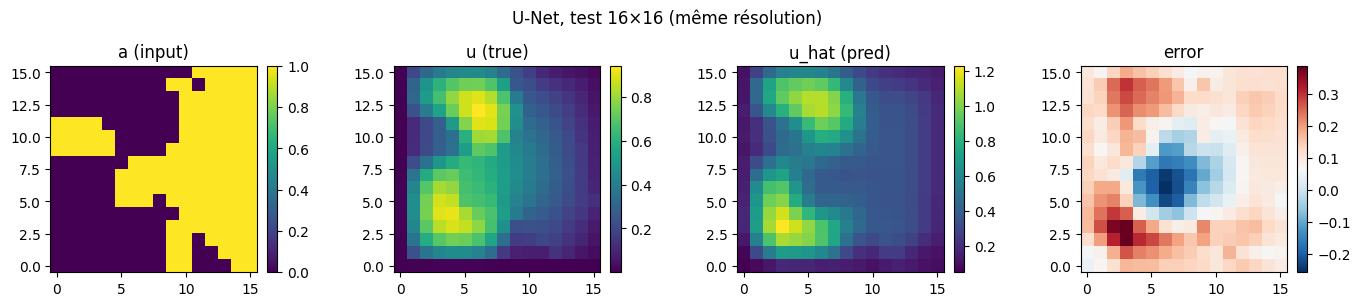

U-Net test32: L2=0.6976 | H1=1.1742


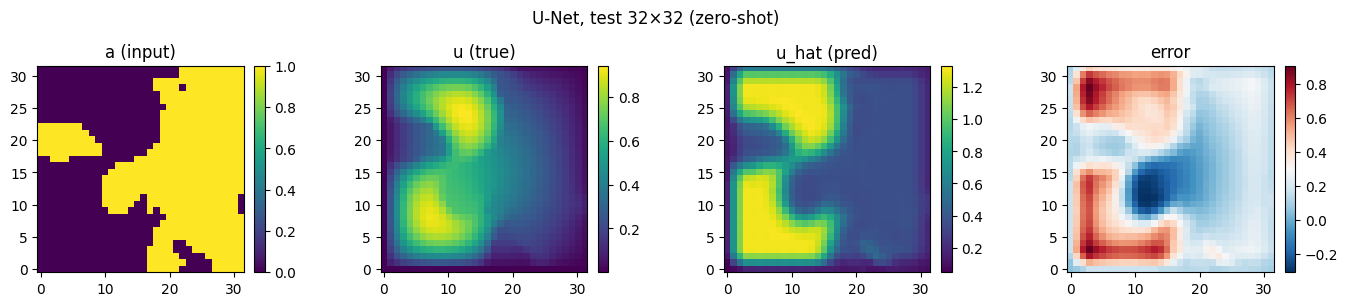

In [11]:
torch.manual_seed(0)
unet = UNetSmall(
    in_channels=in_channels,
    out_channels=1,
    base=config["unet"]["base_channels"],
    depth=config["unet"]["depth"],
)
print("U-Net params:", count_params(unet))

unet = train_with_trainer(unet, "U-Net")

results_main = {"U-Net": {}}
for res, loader in test_loaders.items():
    m = evaluate_quick(unet, loader)
    results_main["U-Net"][res] = m
    print(f"U-Net test{res}: L2={m['l2']:.4f} | H1={m['h1']:.4f}")
    tag = "same resolution" if res == x.shape[-1] else "zero-shot"
    show_batch_predictions(unet, loader, title=f"U-Net, test {res}×{res} ({tag})")

## 8. Main model: (T)FNO (Fourier Neural Operator)

We instantiate a **TFNO** (factorized version) if `factorization` is not `None`, otherwise a standard **FNO**.

### Role of the parameters (see section 0bis)
- `n_modes=(m1,m2)`: number of Fourier modes kept (low frequencies).
  - Larger -> more detail possible (but higher cost).
- `hidden_channels`: internal width (model capacity).
- `n_layers`: number of stacked blocks (depth).

### TFNO vs FNO
- `TFNO` (factorization="tucker"): approximates some weight tensors to reduce memory/time cost.
- `FNO`: more "direct", but can become expensive when the size grows a lot.

A good starting point:
- small `hidden_channels` (8–32),
- moderate `n_modes` (8–16),
- small `n_epochs` (5–20).

---


In [12]:
# Model imports (exact names vary across versions)
try:
    from neuralop.models import FNO as FNO2d
    from neuralop.models import TFNO as TFNO2d
except Exception:
    from neuralop.models import FNO2d as FNO2d
    from neuralop.models import TFNO2d as TFNO2d


## 9. Train the (T)FNO + evaluate (32×32, 64×64)

Compare directly with the U-Net results.


In [13]:
fcfg = config["fno"]

def build_fno(n_modes=None, hidden_channels=None, n_layers=None, factorization="cfg", rank=None):
    n_modes = fcfg["n_modes"] if n_modes is None else n_modes
    hidden = fcfg["hidden_channels"] if hidden_channels is None else hidden_channels
    n_layers = fcfg["n_layers"] if n_layers is None else n_layers
    factorization = fcfg["factorization"] if factorization == "cfg" else factorization
    rank = fcfg["rank"] if rank is None else rank
    common = dict(
        n_modes=tuple(n_modes), in_channels=in_channels, out_channels=1,
        hidden_channels=hidden, n_layers=n_layers,
        # neuralop 2.x parameterizes the projection by a ratio: keep ~projection_channels channels
        projection_channel_ratio=max(1, fcfg["projection_channels"] // hidden),
    )
    if factorization is None:
        return FNO2d(**common)
    return TFNO2d(**common, factorization=factorization,
                  implementation=fcfg["implementation"], rank=rank)

torch.manual_seed(0)
tfno = build_fno()
print(type(tfno).__name__, "| params:", count_params(tfno), "| U-Net params:", count_params(unet))

tfno = train_with_trainer(tfno, "TFNO")

results_main["TFNO"] = {}
for res, loader in test_loaders.items():
    m = evaluate_quick(tfno, loader)
    results_main["TFNO"][res] = m
    print(f"TFNO test{res}: L2={m['l2']:.4f} | H1={m['h1']:.4f}")

TFNO | params: 23037 | U-Net params: 3120977

=== Training TFNO (Trainer API: new) ===
Training on 256 samples
Testing on [50, 50] samples         on resolutions [16, 32].


Raw outputs of shape torch.Size([16, 1, 16, 16])


[0] time=0.60, avg_loss=0.8425, train_err=13.4794


Eval: 16_l2=0.3639, 16_h1=0.6216, 32_l2=0.3625, 32_h1=0.6876


[1] time=0.57, avg_loss=0.5534, train_err=8.8550


...

Eval: 16_l2=0.1929, 16_h1=0.2883, 32_l2=0.2143, 32_h1=0.4106


[9] time=0.55, avg_loss=0.2743, train_err=4.3893


Eval: 16_l2=0.1821, 16_h1=0.2737, 32_l2=0.2068, 32_h1=0.4026


TFNO test16: L2=0.1821 | H1=0.2737


TFNO test32: L2=0.2068 | H1=0.4026


,test16 L2,test16 H1,test32 L2,test32 H1
model,,,,
U-Net,0.3329,0.4389,0.6976,1.1742
TFNO,0.1821,0.2737,0.2068,0.4026


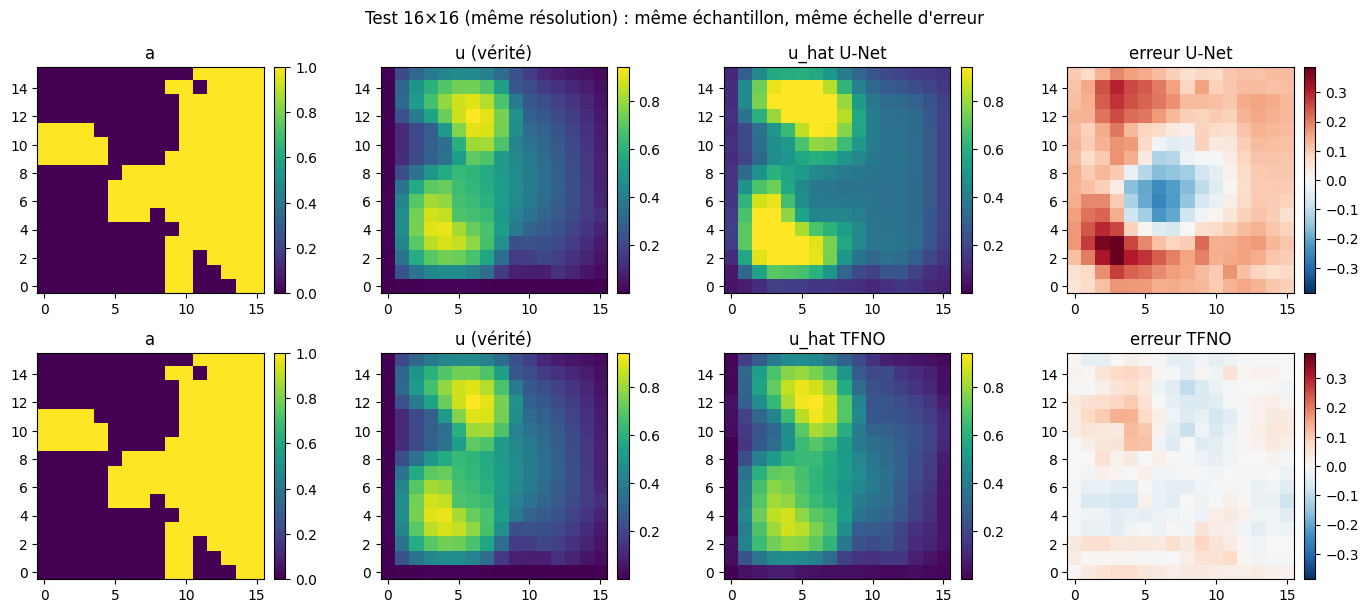

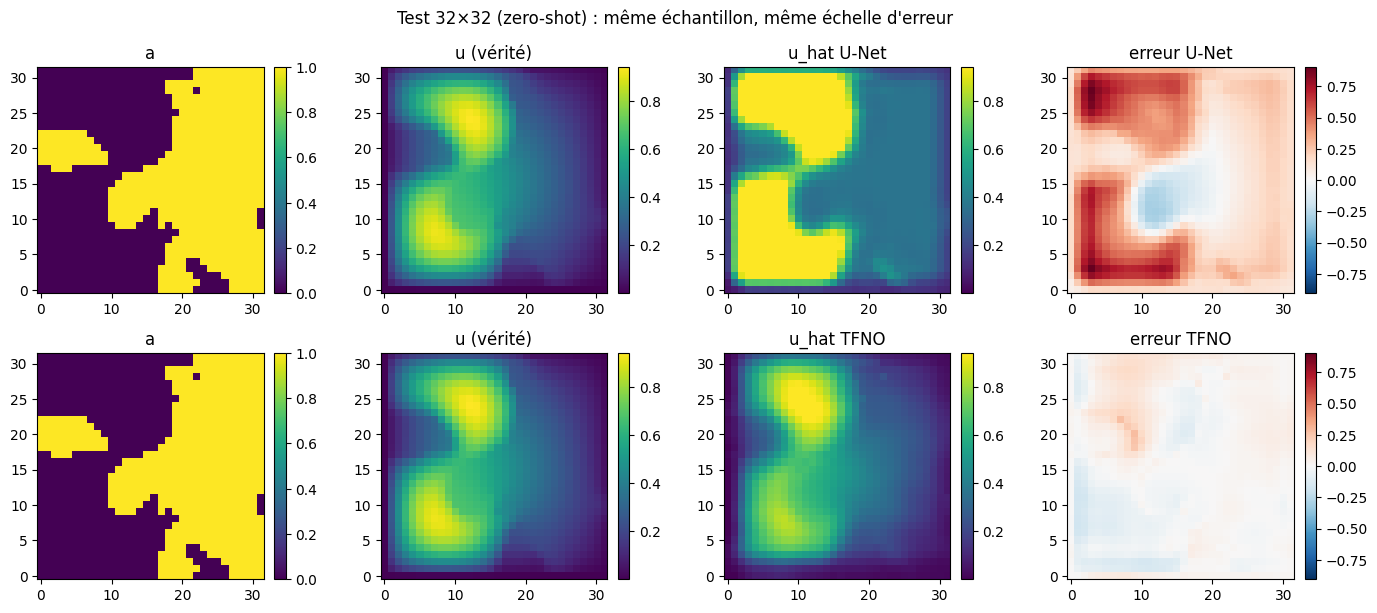

In [14]:
import pandas as pd

rows = []
for name, per_res in results_main.items():
    row = {"model": name}
    for res, m in per_res.items():
        row[f"test{res} L2"] = m["l2"]; row[f"test{res} H1"] = m["h1"]
    rows.append(row)
display(pd.DataFrame(rows).set_index("model").round(4))


@torch.no_grad()
def compare_models(models, loader, idx=0, title=""):
    batch = next(iter(loader))
    preds = {n: predict(m, batch) for n, m in models.items()}
    xb, yb, _ = next(iter(preds.values()))
    a, u = xb[idx, 0].cpu(), yb[idx, 0].cpu()
    errs = {n: (p[2][idx, 0].cpu() - u) for n, p in preds.items()}
    vmax = max(e.abs().max().item() for e in errs.values())
    n = len(models)
    fig, axs = plt.subplots(n, 4, figsize=(14, 3.1 * n))
    for i, (name, p) in enumerate(preds.items()):
        uhat = p[2][idx, 0].cpu()
        panels = [(a, "a"), (u, "u (truth)"), (uhat, f"u_hat {name}"), (errs[name], f"error {name}")]
        for j, (img, t) in enumerate(panels):
            if j == 3:
                im = axs[i, j].imshow(img, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
            elif j in (1, 2):
                im = axs[i, j].imshow(img, origin="lower", vmin=u.min(), vmax=u.max())
            else:
                im = axs[i, j].imshow(img, origin="lower")
            axs[i, j].set_title(t); plt.colorbar(im, ax=axs[i, j], fraction=0.046, pad=0.04)
    plt.suptitle(title); plt.tight_layout(); plt.show()

for res, loader in test_loaders.items():
    tag = "same resolution" if res == x.shape[-1] else "zero-shot"
    compare_models({"U-Net": unet, "TFNO": tfno}, loader, title=f"Test {res}×{res} ({tag}): same sample, same error scale")

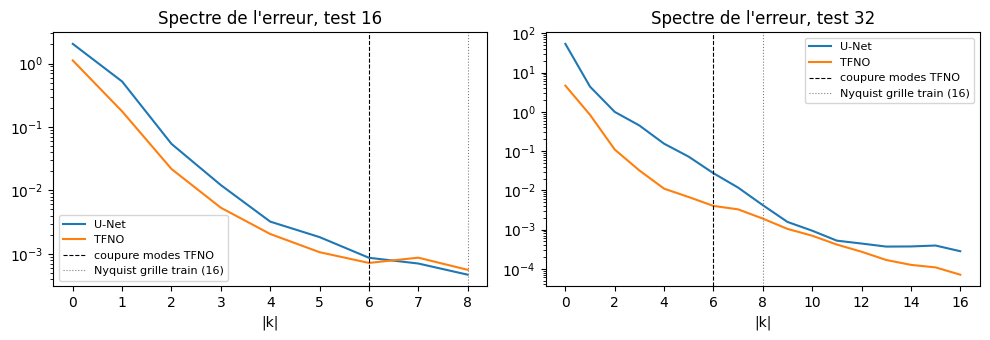

In [15]:
# Where are the errors in frequency? Radial spectrum of the error u_hat - u
@torch.no_grad()
def radial_error_spectrum(model, loader, dp=None):
    acc, n = None, 0
    for batch in loader:
        _, yb, pred = predict(model, batch, dp)
        e = (pred - yb)[:, 0]
        E = torch.fft.fftshift(torch.fft.fft2(e, norm="ortho"), dim=(-2, -1)).abs() ** 2
        acc = E.sum(0) if acc is None else acc + E.sum(0)
        n += e.shape[0]
    P = (acc / n).cpu().numpy()
    H, W = P.shape
    ky, kx = np.meshgrid(np.arange(H) - H // 2, np.arange(W) - W // 2, indexing="ij")
    kr = np.sqrt(kx**2 + ky**2).round().astype(int)
    return np.bincount(kr.ravel(), P.ravel()) / np.maximum(np.bincount(kr.ravel()), 1)

fig, axs = plt.subplots(1, len(test_loaders), figsize=(5 * len(test_loaders), 3.5))
axs = np.atleast_1d(axs)
for ax, (res, loader) in zip(axs, test_loaders.items()):
    for name, m in [("U-Net", unet), ("TFNO", tfno)]:
        s = radial_error_spectrum(m, loader)
        ax.semilogy(s[: res // 2 + 1], label=name)
    ax.axvline(fcfg["n_modes"][0] // 2, ls="--", c="k", lw=0.8, label="TFNO mode cutoff")
    ax.axvline(8, ls=":", c="gray", lw=0.8, label="training-grid Nyquist (16)")
    ax.set_title(f"Error spectrum, test {res}"); ax.set_xlabel("|k|"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### U-Net vs TFNO analysis (base config, 10 epochs)

| Model | params | test16 L2 | test16 H1 | test32 L2 (zero-shot) | test32 H1 (zero-shot) |
|---|---:|---:|---:|---:|---:|
| U-Net | 3,120,977 | 0.333 | 0.439 | 0.698 | 1.174 |
| TFNO | 23,037 | 0.182 | 0.274 | 0.207 | 0.403 |

* **At the same resolution (16×16)**, the TFNO has an L2 error about half as large with **135 times fewer parameters**.
* **Zero-shot (32×32)**, the gap becomes huge. The TFNO degrades little (L2 from 0.18 to 0.21), while the U-Net doubles its error. The figure above shows that the U-Net does not make a small error on details: it **massively overestimates the amplitude** of $u$ in low-permeability regions, while respecting the geometry of $a$.
* **The error spectrum** confirms it: at 32×32, the U-Net error is dominated by $|k|=0,1$, i.e. a global bias, about 10 times above the TFNO's. For both models the error is mostly low-frequency: for an elliptic PDE, getting the global amplitude wrong costs more than getting the details wrong.

## 10. Ablations: protocol + interpretation

The goal here is not endless tuning, but to **understand** what the hyperparameters control.

- Pick a "base setting" (the one of this notebook).
- **Change one parameter at a time** and keep everything else identical.
- On CPU: use `n_train=128–256` and `n_epochs=5–10` so that it runs fast.
- For each run, record:
  - `L2` and `H1` on the 32×32 test
  - `L2` and `H1` on the 64×64 test
  - 1 or 2 qualitative figures

### Results table
A useful table to fill in:

| Model | train loss | n_modes | hidden | n_layers | test32 L2 | test32 H1 | test64 L2 | test64 H1 | comment |
|---|---|---:|---:|---:|---:|---:|---:|---:|---|
| U‑Net | (—) | (—) | base=… | depth=… | … | … | … | … | … |
| TFNO | l2/h1 | (m1,m2) | … | … | … | … | … | … | … |
| … | … | … | … | … | … | … | … | … | … |

### Suggested ablations
1) **Loss**: `training_loss="l2"` vs `"h1"`  
   - What is the impact of the training loss?

2) **Modes**: `n_modes=(8,8)`, `(12,12)`, `(16,16)`  
   - What do you observe?

3) **Capacity**: `hidden_channels=8, 16, 32`  
   - What do you observe?

4) (GPU option) **TFNO vs FNO**: set `factorization=None` and compare.

### Interpretation questions (short answers)
1. In what ways do the U‑Net and the (T)FNO make "different" errors (smoothing, artifacts, global bias...)?
2. Why does `n_modes` strongly control the level of detail?
3. What does "zero-shot super-resolution" mean in this context? Is it really "super-resolution" in the image sense?

### Bonus
Compute and compare $\|\mathbf{v}\|$ with $\mathbf{v}=-a\nabla u$ for the ground truth and the prediction $\hat u$.
This is a good "physical" test because the flux depends on the **gradients**.

---


### 10.1 Protocol

All runs use the base configuration (256 samples at 16×16, 10 epochs, Adam 5e-3, cosine schedule) and **change a single parameter**. Each configuration is run with **2 seeds** (different initializations) to estimate the noise level: a difference smaller than the standard deviation across seeds cannot be interpreted.

In [16]:
import contextlib, io, time

def run_experiment(kind="tfno", loss="h1", seed=0, n_epochs=None,
                   tl=None, tls=None, dp=None, **fno_kw):
    tl = train_loader if tl is None else tl
    tls = test_loaders if tls is None else tls
    dp = data_processor if dp is None else dp
    n_epochs = config["opt"]["n_epochs"] if n_epochs is None else n_epochs
    torch.manual_seed(seed); np.random.seed(seed)
    if kind == "unet":
        model = UNetSmall(in_channels, 1, base=config["unet"]["base_channels"], depth=config["unet"]["depth"])
    else:
        model = build_fno(**fno_kw)
    model = model.to(device)
    optimizer, scheduler = make_optimizer_and_scheduler(model, config["opt"])
    t0 = time.time()
    with contextlib.redirect_stdout(io.StringIO()), warnings.catch_warnings():
        warnings.simplefilter("ignore")
        trainer = TrainerCls(model=model, n_epochs=n_epochs, device=device, verbose=False,
                             data_processor=dp, eval_interval=10**6)
        trainer.train(train_loader=tl, test_loaders=tls, optimizer=optimizer, scheduler=scheduler,
                      regularizer=False, training_loss=l2loss if loss == "l2" else h1loss,
                      eval_losses=eval_losses)
    out = {"params": count_params(model), "time (s)": time.time() - t0}
    for res, loader in tls.items():
        m = evaluate_quick(model, loader, dp)
        out[f"test{res} L2"] = m["l2"]; out[f"test{res} H1"] = m["h1"]
    return out, model


f0 = config["fno"]
EXPERIMENTS = [
    # (name, group, kwargs)
    ("U-Net (h1)",          "baseline", dict(kind="unet", loss="h1")),
    ("U-Net (l2)",          "loss",     dict(kind="unet", loss="l2")),
    ("TFNO base (h1)",      "baseline", dict()),
    ("TFNO loss l2",        "loss",     dict(loss="l2")),
    ("TFNO modes (4,4)",    "modes",    dict(n_modes=(4, 4))),
    ("TFNO modes (8,8)",    "modes",    dict(n_modes=(8, 8))),
    ("TFNO modes (16,16)",  "modes",    dict(n_modes=(16, 16))),
    ("TFNO hidden 8",       "capacity", dict(hidden_channels=8)),
    ("TFNO hidden 32",      "capacity", dict(hidden_channels=32)),
    ("TFNO n_layers 2",     "capacity", dict(n_layers=2)),
    ("Full FNO (fact=None)", "TFNO vs FNO", dict(factorization=None)),
]
SEEDS = [0, 1]

records, models_seed0 = [], {}
for name, group, kw in EXPERIMENTS:
    for s in SEEDS:
        r, mdl = run_experiment(seed=s, **kw)
        records.append({"config": name, "group": group, "seed": s, **r})
        if s == 0:
            models_seed0[name] = mdl
    last = records[-1]
    print(f"{name:24s} " + " | ".join(f"{k}={v:.3f}" for k, v in last.items() if "test" in k))

df = pd.DataFrame(records)

U-Net (h1)               test16 L2=0.199 | test16 H1=0.264 | test32 L2=0.854 | test32 H1=1.174


U-Net (l2)               test16 L2=0.229 | test16 H1=0.376 | test32 L2=2.477 | test32 H1=5.196


TFNO base (h1)           test16 L2=0.192 | test16 H1=0.288 | test32 L2=0.195 | test32 H1=0.382


TFNO loss l2             test16 L2=0.194 | test16 H1=0.325 | test32 L2=0.207 | test32 H1=0.466


TFNO modes (4,4)         test16 L2=0.199 | test16 H1=0.348 | test32 L2=0.220 | test32 H1=0.493


...

TFNO modes (16,16)       test16 L2=0.181 | test16 H1=0.265 | test32 L2=0.200 | test32 H1=0.405


TFNO hidden 8            test16 L2=0.201 | test16 H1=0.310 | test32 L2=0.206 | test32 H1=0.425


TFNO hidden 32           test16 L2=0.188 | test16 H1=0.281 | test32 L2=0.210 | test32 H1=0.400


TFNO n_layers 2          test16 L2=0.205 | test16 H1=0.333 | test32 L2=0.210 | test32 H1=0.443


Full FNO (fact=None)     test16 L2=0.178 | test16 H1=0.263 | test32 L2=0.190 | test32 H1=0.384


,,params,test16 L2,test16 H1,test32 L2,test32 H1,time (s)
config,group,,,,,,
U-Net (h1),baseline,3120977,0.266 ± 0.094,0.352 ± 0.124,0.776 ± 0.111,1.174 ± 0.000,7.4
U-Net (l2),loss,3120977,0.435 ± 0.291,0.683 ± 0.434,1.555 ± 1.304,3.094 ± 2.973,7.4
TFNO base (h1),baseline,23037,0.187 ± 0.007,0.281 ± 0.010,0.201 ± 0.008,0.392 ± 0.014,6.3
TFNO loss l2,loss,23037,0.182 ± 0.017,0.306 ± 0.026,0.196 ± 0.016,0.441 ± 0.034,6.1
"TFNO modes (4,4)",modes,7737,0.208 ± 0.013,0.351 ± 0.005,0.226 ± 0.008,0.482 ± 0.016,5.2
"TFNO modes (8,8)",modes,12733,0.205 ± 0.013,0.320 ± 0.008,0.216 ± 0.011,0.438 ± 0.003,5.5
"TFNO modes (16,16)",modes,31369,0.182 ± 0.002,0.273 ± 0.011,0.207 ± 0.010,0.443 ± 0.054,6.6
TFNO hidden 8,capacity,6121,0.204 ± 0.004,0.320 ± 0.015,0.210 ± 0.005,0.433 ± 0.011,4.9
TFNO hidden 32,capacity,91789,0.172 ± 0.022,0.259 ± 0.031,0.194 ± 0.023,0.377 ± 0.032,7.9


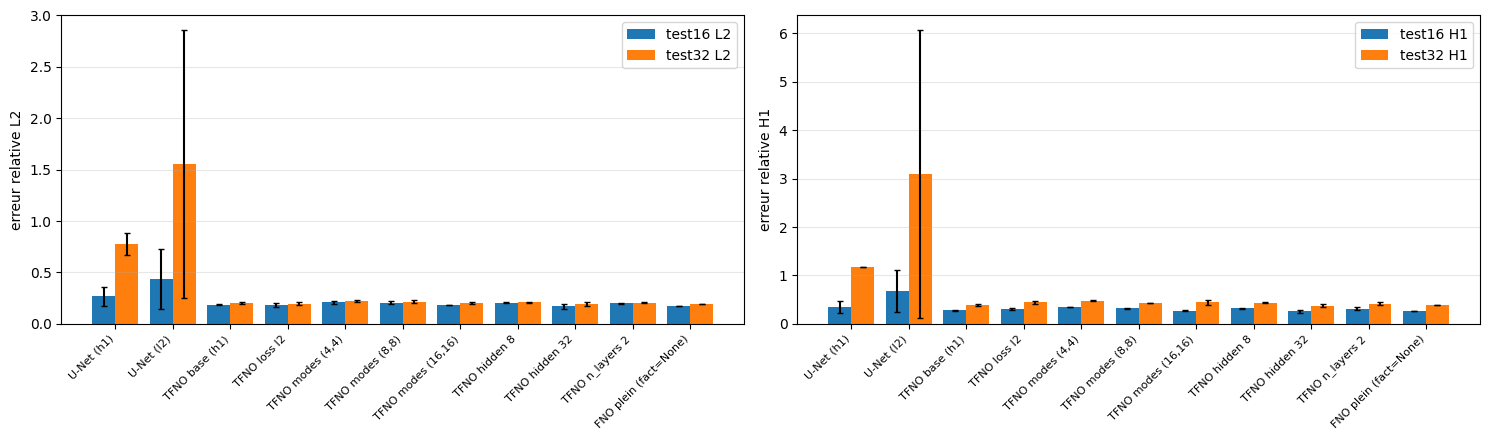

In [17]:
metric_cols = [c for c in df.columns if c.startswith("test")]
agg = df.groupby(["config", "group"], sort=False)[metric_cols + ["params", "time (s)"]].mean()
std = df.groupby(["config", "group"], sort=False)[metric_cols].std()

# Table in the requested format (mean ± standard deviation over 2 seeds)
table = pd.DataFrame(index=agg.index)
table["params"] = agg["params"].astype(int)
for c in metric_cols:
    table[c] = [f"{m:.3f} ± {s:.3f}" for m, s in zip(agg[c], std[c])]
table["time (s)"] = agg["time (s)"].round(1)
display(table)

# Visualization: relative L2 error per test resolution
fig, axs = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, metric in zip(axs, ["L2", "H1"]):
    cols = [c for c in metric_cols if c.endswith(metric)]
    names = [i[0] for i in agg.index]
    w = 0.8 / len(cols)
    for k, c in enumerate(cols):
        ax.bar(np.arange(len(names)) + k * w, agg[c], w, yerr=std[c], capsize=2, label=c)
    ax.set_xticks(np.arange(len(names)) + w * (len(cols) - 1) / 2)
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(f"relative error {metric}"); ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

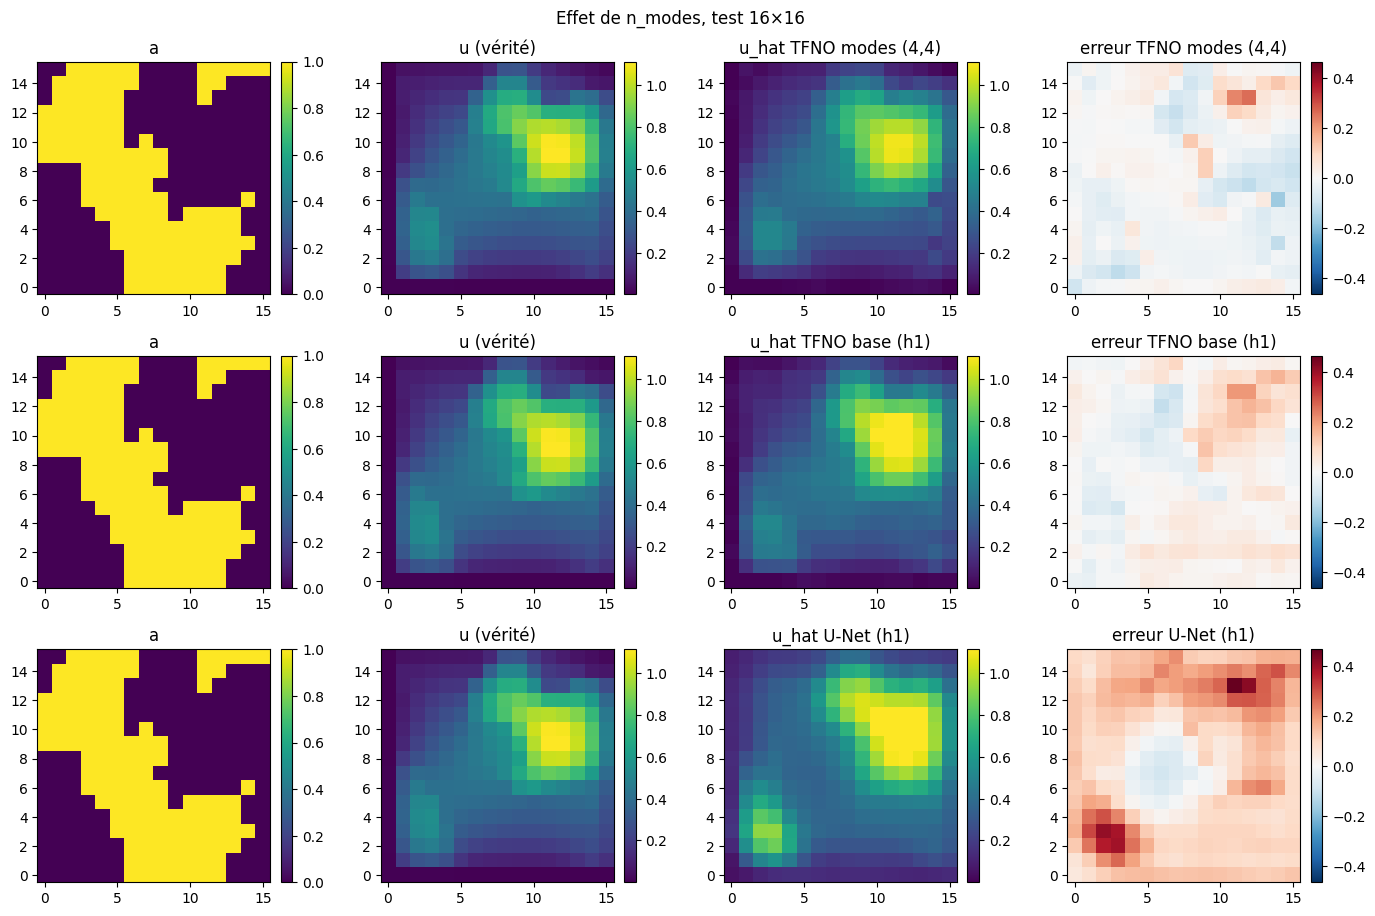

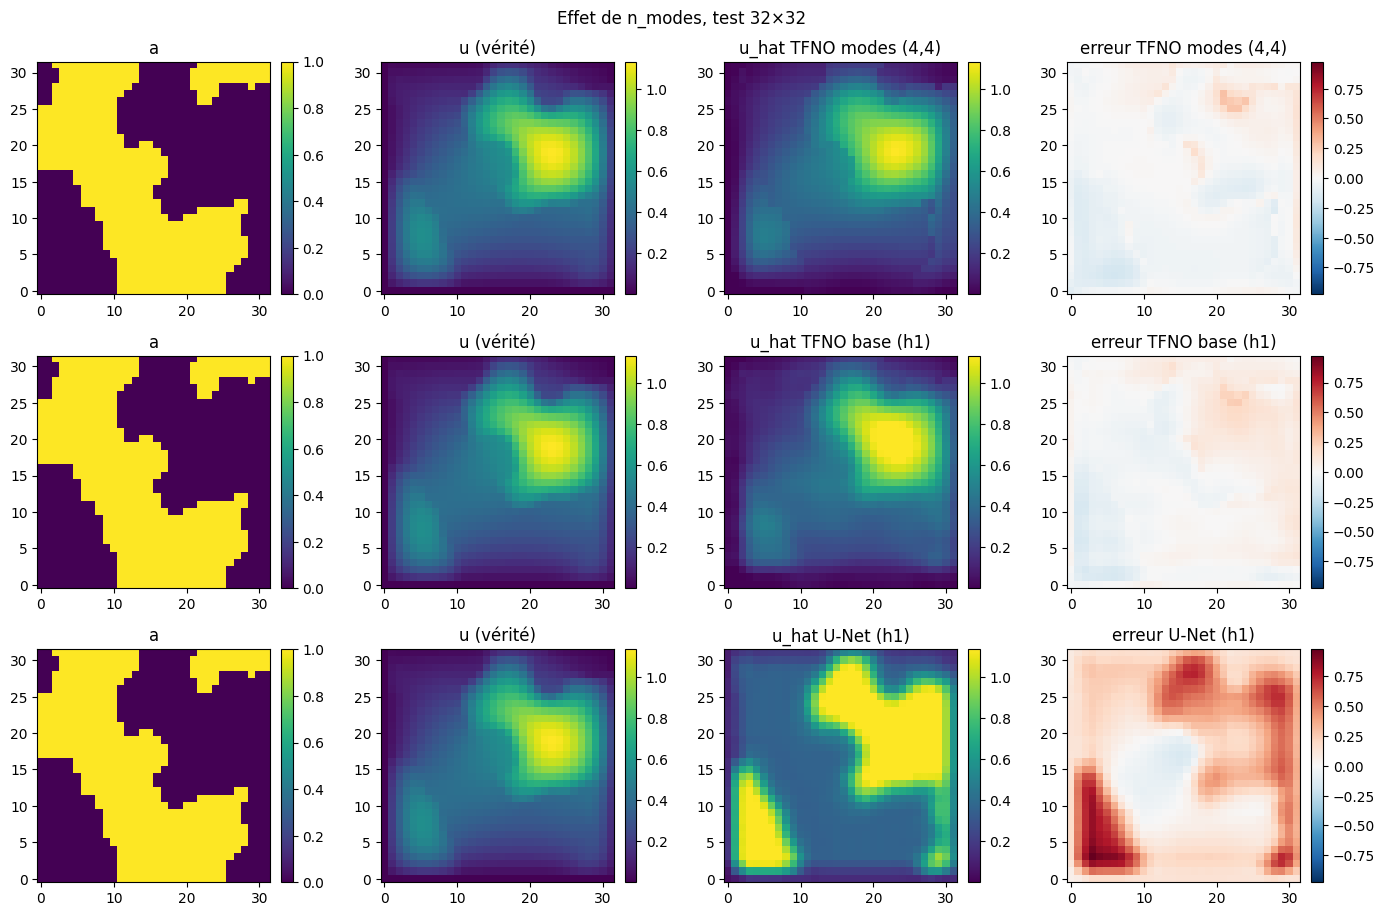

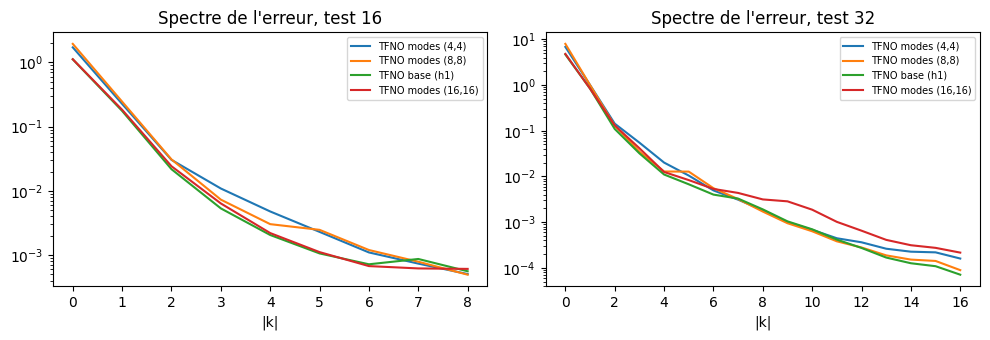

In [18]:
# Qualitative: effect of n_modes on the same prediction (test at the training resolution, then zero-shot)
for res, loader in test_loaders.items():
    compare_models({k: models_seed0[k] for k in ["TFNO modes (4,4)", "TFNO base (h1)", "U-Net (h1)"]},
                   loader, idx=3, title=f"Effect of n_modes, test {res}×{res}")

fig, axs = plt.subplots(1, len(test_loaders), figsize=(5 * len(test_loaders), 3.5))
axs = np.atleast_1d(axs)
for ax, (res, loader) in zip(axs, test_loaders.items()):
    for name in ["TFNO modes (4,4)", "TFNO modes (8,8)", "TFNO base (h1)", "TFNO modes (16,16)"]:
        ax.semilogy(radial_error_spectrum(models_seed0[name], loader)[: res // 2 + 1], label=name)
    ax.set_title(f"Error spectrum, test {res}"); ax.set_xlabel("|k|"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

### 10.2 Additional ablation: data / training budget

All the ablations above are run in a heavily under-trained regime (256 samples, 10 epochs, while the cosine scheduler is set for 50). To check that the conclusions are not an artifact of this regime, the U-Net and TFNO (base config) are rerun with 1000 samples and 50 epochs.

In [19]:
tl_big, tls_big, dp_big = load_darcy(1000, dcfg["test_resolutions"], dcfg["n_tests"],
                                     dcfg["test_batch_sizes"], dcfg["batch_size"])
budget_rows, budget_models = [], {}
for name, kw in [("U-Net (h1)", dict(kind="unet")), ("TFNO base (h1)", dict())]:
    r, mdl = run_experiment(n_epochs=50, tl=tl_big, tls=tls_big, dp=dp_big, **kw)
    budget_models[name] = mdl
    budget_rows.append({"config": name + ", n_train=1000, 50 ep.", **r})
display(pd.DataFrame(budget_rows).set_index("config").round(4))

Loading test db for resolution 16 with 64 samples 
Loading test db for resolution 32 with 64 samples 


,params,time (s),test16 L2,test16 H1,test32 L2,test32 H1
config,,,,,,
"U-Net (h1), n_train=1000, 50 ep.",3120977,272.4184,0.2232,0.3335,0.5623,1.0783
"TFNO base (h1), n_train=1000, 50 ep.",23037,102.4455,0.0771,0.1542,0.1063,0.2830


### 10.3 Bonus: "physical" test on the flux $\mathbf{v}=-a\nabla u$

The input `a` of the dataset is binary. In the original benchmark (Li et al., 2021) the permeability is 12 or 3 depending on the phase, so we reconstruct $a = 3 + 9\,\mathbb{1}_{a=1}$ (an assumption on the phase assignment, with no effect on the relative comparison). The gradient is computed with centered differences on interior points, and we measure the relative error $\|\mathbf{v}_{\text{pred}}-\mathbf{v}_{\text{true}}\|_2/\|\mathbf{v}_{\text{true}}\|_2$ (vector error), averaged over the test set.

,test16 err. rel. u (L2),test16 err. rel. flux v,test32 err. rel. u (L2),test32 err. rel. flux v
model,,,,
U-Net (h1),0.333,0.590,0.698,1.341
U-Net (l2),0.641,1.000,0.633,1.000
TFNO base (h1),0.182,0.352,0.207,0.448
TFNO loss l2,0.170,0.394,0.184,0.525


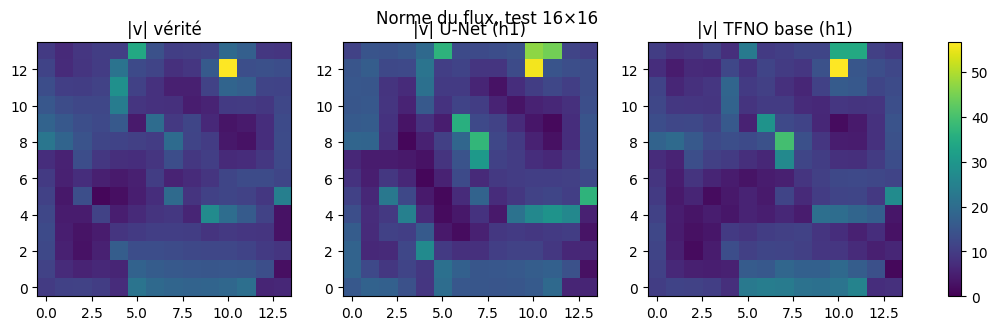

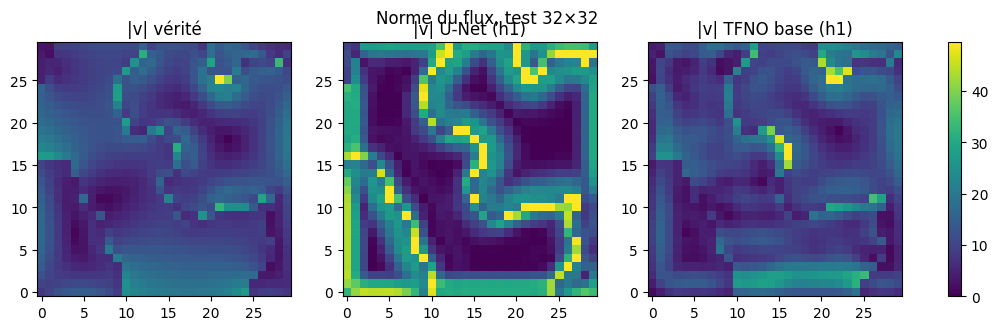

In [20]:
def flux(a01, u):
    """a01, u: (B, H, W). Returns vx, vy on the interior (B, H-2, W-2)."""
    a = 3.0 + 9.0 * a01
    h = 1.0 / u.shape[-1]
    du_dx = (u[:, 2:, 1:-1] - u[:, :-2, 1:-1]) / (2 * h)
    du_dy = (u[:, 1:-1, 2:] - u[:, 1:-1, :-2]) / (2 * h)
    ac = a[:, 1:-1, 1:-1]
    return -ac * du_dx, -ac * du_dy

@torch.no_grad()
def flux_error(model, loader, dp=None):
    num, n = 0.0, 0
    for batch in loader:
        xb, yb, pred = predict(model, batch, dp)
        vx, vy = flux(xb[:, 0], yb[:, 0]); px, py = flux(xb[:, 0], pred[:, 0])
        e = torch.sqrt(((px - vx) ** 2 + (py - vy) ** 2).sum((-2, -1)))
        r = torch.sqrt((vx ** 2 + vy ** 2).sum((-2, -1)))
        num += (e / r).sum().item(); n += xb.shape[0]
    return num / n

flux_models = {
    "U-Net (h1)": models_seed0["U-Net (h1)"], "U-Net (l2)": models_seed0["U-Net (l2)"],
    "TFNO base (h1)": models_seed0["TFNO base (h1)"], "TFNO loss l2": models_seed0["TFNO loss l2"],
}
rows = []
for name, m in flux_models.items():
    row = {"model": name}
    for res, loader in test_loaders.items():
        row[f"test{res} rel. err. u (L2)"] = evaluate_quick(m, loader)["l2"]
        row[f"test{res} rel. err. flux v"] = flux_error(m, loader)
    rows.append(row)
display(pd.DataFrame(rows).set_index("model").round(3))

# Figure: true vs predicted |v|, on one sample at each resolution
for res, loader in test_loaders.items():
    batch = next(iter(loader)); i = 3
    fig, axs = plt.subplots(1, 3, figsize=(12, 3.3))
    xb, yb, _ = predict(unet, batch)
    vx, vy = flux(xb[:, 0], yb[:, 0]); sp_true = torch.sqrt(vx**2 + vy**2)[i]
    vmax = sp_true.max().item()
    im = axs[0].imshow(sp_true, origin="lower", vmin=0, vmax=vmax); axs[0].set_title("|v| truth")
    for ax, name in zip(axs[1:], ["U-Net (h1)", "TFNO base (h1)"]):
        _, _, p = predict(models_seed0[name], batch)
        px, py = flux(xb[:, 0], p[:, 0])
        ax.imshow(torch.sqrt(px**2 + py**2)[i], origin="lower", vmin=0, vmax=vmax); ax.set_title(f"|v| {name}")
    plt.colorbar(im, ax=axs, fraction=0.02)
    plt.suptitle(f"Flux magnitude, test {res}×{res}"); plt.show()

### 10.4 Results table and interpretation

Mean over 2 seeds; the standard deviation is in the full table above. Training at 16×16, 256 samples, 10 epochs. **Resolution 64 could not be tested here** (no access to Zenodo from my environment); on Colab the same cell loads it automatically.

| Model | train loss | n_modes | hidden | n_layers | params | test16 L2 | test16 H1 | test32 L2 | test32 H1 | comment |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|---|
| U-Net | h1 | n/a | base=16 | depth=4 | 3.12 M | 0.266 | 0.352 | 0.776 | 1.174 | high variance across seeds; zero-shot broken |
| U-Net | l2 | n/a | base=16 | depth=4 | 3.12 M | 0.435 | 0.683 | 1.555 | 3.094 | seed 0 collapses (almost flat field) |
| TFNO | h1 | (12,12) | 16 | 4 | 23 k | 0.187 | 0.281 | 0.201 | 0.392 | reference |
| TFNO | l2 | (12,12) | 16 | 4 | 23 k | 0.182 | 0.306 | 0.196 | 0.441 | same L2, worse H1 |
| TFNO | h1 | (4,4) | 16 | 4 | 7.7 k | 0.208 | 0.351 | 0.226 | 0.482 | too smooth |
| TFNO | h1 | (8,8) | 16 | 4 | 12.7 k | 0.205 | 0.320 | 0.216 | 0.438 | |
| TFNO | h1 | (16,16) | 16 | 4 | 31 k | 0.182 | 0.273 | 0.207 | 0.443 | best at 16, worse and unstable at 32 |
| TFNO | h1 | (12,12) | 8 | 4 | 6.1 k | 0.204 | 0.320 | 0.210 | 0.433 | |
| TFNO | h1 | (12,12) | 32 | 4 | 92 k | 0.172 | 0.259 | 0.194 | 0.377 | gain within the noise (± 0.02) |
| TFNO | h1 | (12,12) | 16 | 2 | 13 k | 0.201 | 0.314 | 0.206 | 0.420 | |
| Full FNO | h1 | (12,12) | 16 | 4 | 91 k | 0.177 | 0.267 | 0.193 | 0.385 | very stable (± 0.001) |
| U-Net, 1000 samples, 50 ep. | h1 | n/a | base=16 | depth=4 | 3.12 M | 0.223 | 0.334 | 0.562 | 1.078 | more budget does not fix zero-shot |
| TFNO, 1000 samples, 50 ep. | h1 | (12,12) | 16 | 4 | 23 k | 0.077 | 0.154 | 0.106 | 0.283 | |

#### Ablation 1: training loss (l2 vs h1)
For the TFNO, the L2 error is the same with both losses (0.182 vs 0.187, within the noise), but training with **H1 clearly improves the H1 metric**: 0.281 vs 0.306 at 16, and 0.392 vs 0.441 zero-shot. Each loss optimizes what it measures: H1 penalizes gradients, hence the fine structure of the field. The flux bonus confirms it: the relative error on $\mathbf{v}$ drops from 0.394 to 0.352 at 16 and from 0.525 to 0.448 at 32 with H1, while the L2 error on $u$ is even slightly better for the model trained with L2. For a physical quantity that depends on $\nabla u$, H1 is the right choice. On the U-Net side, L2 training collapsed for one seed (almost constant prediction: flux error of exactly 1.0), a sign that the baseline is also less stable at this learning rate.

#### Ablation 2: n_modes
At the training resolution, more modes give a lower error, especially in H1 (0.351, 0.320, 0.281, 0.273 for 4, 8, 12, 16 modes): the fine structure is better recovered, and the error spectrum of (4,4) shows excess error around $|k|=3$ to $5$, just above its cutoff. But zero-shot, **(16,16) is worse than (12,12)** and much more variable (H1 0.443 ± 0.054). At 16×16, 16 modes cover the whole spectrum up to Nyquist ($|k|=8$), including the frequencies most polluted by aliasing. Applied to a 32×32 grid where these frequencies are really present, they produce excess error beyond $|k|=8$ (visible in the spectrum). `n_modes` should therefore stay below the training resolution when aiming for resolution generalization.

#### Ablation 3: capacity (hidden_channels, n_layers)
Going from 8 to 16, then 32 channels improves the error (0.204, 0.187, 0.172 at 16), but the gains become comparable to the variance across seeds, especially zero-shot (0.210, 0.201, 0.194). Two layers instead of four cost a little (0.201). With 256 samples and 10 epochs, we are **limited by data and optimization, not by capacity**: as experiment 10.2 shows, 1000 samples and 50 epochs divide the error by 2.4 without touching the model.

#### Ablation 4: TFNO vs FNO
The full FNO (91 k parameters) does slightly better (0.177 vs 0.187) and varies less across seeds. Tucker factorization at rank 0.2 divides the number of parameters by 4 for about 5% more error: exactly the expected trade-off. The benefit of the TFNO grows with `n_modes` and `hidden_channels`, since the number of spectral weights of a full FNO grows as `hidden² × m1 × m2`.

#### Question 1: do the U-Net and the (T)FNO make different errors?
Yes, very clearly.
* **U-Net.** At the training resolution, errors are larger and above all highly variable across seeds (0.266 ± 0.094). Zero-shot, the error is not a matter of detail: it is a **global amplitude bias** (error spectrum dominated by $|k|=0$); the predicted field reproduces the geometry of $a$ well but with a strongly overestimated amplitude. This is consistent with its kernels being defined **in pixels**: at 32×32, each convolution and the bottleneck cover a physical area twice as small, whereas the amplitude of $u$ depends on the distance to the boundaries, a global piece of information. Even with 1000 samples and 50 epochs, the zero-shot error stays at 0.56: the problem is structural.
* **TFNO.** Smooth, low error of the same nature at both resolutions, slightly concentrated at the interfaces between the phases of $a$ (discontinuities that truncated modes cannot represent exactly). Its only zero-shot failure mode appears when too many modes are kept (high-frequency artifacts of ablation 2).

#### Question 2: why does n_modes control the level of detail?
Each spectral layer only multiplies the first `n_modes` Fourier frequencies and sets the others to zero: it is a learned low-pass filter. High frequencies are only handled by the 1×1 pointwise branch and the non-linearities, which are much less expressive for building spatial variations. Fewer modes therefore mean a smoother output (higher H1 error, see (4,4)). There are two limits: nothing can be learned beyond the Nyquist frequency of the training grid, and keeping modes close to Nyquist hurts resolution generalization. Implementation detail: in `neuralop`, `n_modes=(12,12)` corresponds to ±6 frequencies on the first axis and 7 on the second (real transform).

#### Question 3: what does "zero-shot super-resolution" mean?
It means evaluating, **without retraining**, on a grid finer than the training grid. The FNO allows it because its weights are indexed by physical frequencies rather than pixels: it approximates an operator between function spaces, applicable to any discretization (here the error only goes from 0.18 to 0.21, or from 0.077 to 0.106 with more data). It is **not** super-resolution in the image sense: we do not reconstruct a fine image from a coarse one; the model receives the input $a$ **already** at 32×32, and the ground truth comes from a fine solver. The model creates no detail beyond the learned frequencies, and its error at high resolution is larger, not smaller, than at the training resolution. A more accurate term would be "(approximate) discretization invariance".

#### Bonus: the flux as a physical test
The relative error on $\mathbf{v}=-a\nabla u$ is about twice the error on $u$ (TFNO: 0.35 vs 0.18 at 16, 0.45 vs 0.21 at 32), because differentiation amplifies high-frequency errors and $a$ multiplies the errors by 4 in the high-permeability phase. The U-Net reaches 0.59 at 16 and 1.34 at 32: zero-shot, its flux is unusable. This is the most concrete argument for the H1 loss: the TFNO trained with H1 has a better flux than the one trained with L2, while their errors on $u$ are equivalent.

## Bonus: going further by mixing spatial and temporal dependence

In Darcy flow, we learn a **static** operator: $a(x,y)\mapsto u(x,y)$.  
But many physical systems are **spatio-temporal**: we observe a field $u_t(x,y)$ that evolves over time.

A classic example is **2D Navier–Stokes** (incompressible flow), where the state of the fluid (often the vorticity or the velocity) follows a dynamics:
$$
u_{t+1} = \mathcal{F}(u_t)
$$

### Temporal rollout (direct analogue of the RNN lab)
If a model predicts $u_{t+1}$ from $u_t$, we can perform an **autoregressive rollout**:
$$
\hat u_{t+1}=\mathcal{F}(\hat u_t),\ \hat u_{t+2}=\mathcal{F}(\hat u_{t+1}),\dots
$$
As with RNNs, errors can **accumulate** over time (drift).

### Goal of the bonus
- Load a small Navier–Stokes dataset
- Extract a sequence $u_0,\dots,u_T$
- Perform an autoregressive rollout
- Plot the error as a function of time

Below is a command to import the Navier–Stokes data (NeuralOperator).

In [21]:
from neuralop.data.datasets import NavierStokesDataset

### Implementing the Navier–Stokes bonus

NeuralOperator's `NavierStokesDataset` downloads 128×128 data from Zenodo (a large archive) as input/output vorticity pairs. To obtain **full trajectories** $\omega_0,\dots,\omega_T$ and stay runnable on CPU, we generate our own trajectories for the same problem as Li et al. (2021):

$$\partial_t\omega + \mathbf{u}\cdot\nabla\omega = \nu\Delta\omega + f,\qquad \nabla\cdot\mathbf{u}=0,\qquad \omega=\nabla\times\mathbf{u}$$

on the torus $[0,1]^2$, with $\nu=10^{-3}$, forcing $f=0.1\,(\sin 2\pi(x+y)+\cos 2\pi(x+y))$ and an initial condition drawn from a Gaussian random field. Pseudo-spectral solver (Crank–Nicolson for diffusion, Heun for advection, 2/3 de-aliasing) on a 64×64 grid, then subsampled to 32×32. One state is saved per time unit, $T=20$.

Plan: (1) generate the trajectories, (2) train a **one-step** FNO $\omega_t\mapsto\omega_{t+1}$, (3) perform an **autoregressive rollout** from $\omega_0$ and plot the error over time, compared with the "one-step" error (true input at each step) and with persistence ($\hat\omega_{t}=\omega_0$).

Trajectories: (240, 21, 32, 32) | generation 142 s


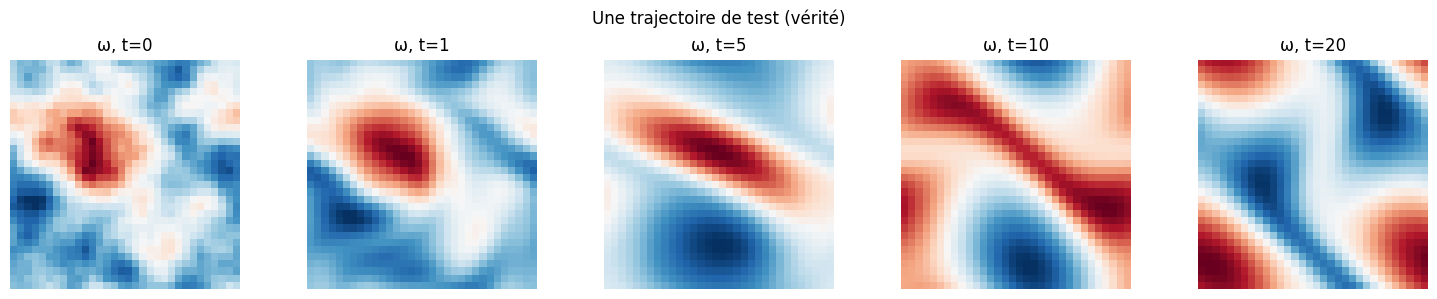

In [22]:
def grf_2d(n, N, alpha=2.5, tau=7.0, gen=None):
    """Periodic Gaussian random field, spectrum (4π²|k|²+τ²)^(-α/2), normalized to std=1."""
    ky = torch.fft.fftfreq(N, d=1.0 / N).view(N, 1)
    kx = torch.fft.rfftfreq(N, d=1.0 / N).view(1, -1)
    spec = (4 * math.pi**2 * (kx**2 + ky**2) + tau**2) ** (-alpha / 2); spec[0, 0] = 0
    c = torch.randn(n, N, N // 2 + 1, dtype=torch.cfloat, generator=gen) * spec
    w = torch.fft.irfft2(c, s=(N, N))
    return w / w.std(dim=(-2, -1), keepdim=True)

def ns_solve(w0, f, visc=1e-3, T=20.0, dt=5e-3, record_every=1.0):
    N = w0.shape[-1]
    ky = torch.fft.fftfreq(N, d=1.0 / N).view(N, 1)
    kx = torch.fft.rfftfreq(N, d=1.0 / N).view(1, -1)
    lap = 4 * math.pi**2 * (kx**2 + ky**2); lap_inv = lap.clone(); lap_inv[0, 0] = 1.0
    kmax = N // 2
    dealias = ((kx.abs() <= 2 / 3 * kmax) & (ky.abs() <= 2 / 3 * kmax)).float()
    f_h, w_h = torch.fft.rfft2(f), torch.fft.rfft2(w0)

    def advection(w_h):                      # transform of u·∇ω
        psi_h = w_h / lap_inv                # -Δψ = ω
        u = torch.fft.irfft2(2j * math.pi * ky * psi_h, s=(N, N))    # u =  ∂ψ/∂y
        v = torch.fft.irfft2(-2j * math.pi * kx * psi_h, s=(N, N))   # v = -∂ψ/∂x
        wx = torch.fft.irfft2(2j * math.pi * kx * w_h, s=(N, N))
        wy = torch.fft.irfft2(2j * math.pi * ky * w_h, s=(N, N))
        return torch.fft.rfft2(u * wx + v * wy) * dealias

    cn_num, cn_den = 1 - 0.5 * dt * visc * lap, 1 + 0.5 * dt * visc * lap
    n_steps, rec = int(round(T / dt)), int(round(record_every / dt))
    traj = [w0.clone()]
    for s in range(1, n_steps + 1):
        N1 = advection(w_h)
        w_pred = (cn_num * w_h + dt * (f_h - N1)) / cn_den
        N2 = advection(w_pred)
        w_h = (cn_num * w_h + dt * (f_h - 0.5 * (N1 + N2))) / cn_den
        if s % rec == 0:
            traj.append(torch.fft.irfft2(w_h, s=(N, N)))
    return torch.stack(traj, 1)            # (B, T+1, N, N)

N_FINE, N_TRAJ_TRAIN, N_TRAJ_TEST = 64, 200, 40
g = torch.Generator().manual_seed(0)
xs = torch.linspace(0, 1, N_FINE + 1)[:-1]
Xg, Yg = torch.meshgrid(xs, xs, indexing="ij")
forcing = 0.1 * (torch.sin(2 * math.pi * (Xg + Yg)) + torch.cos(2 * math.pi * (Xg + Yg)))

t0 = time.time()
W = ns_solve(grf_2d(N_TRAJ_TRAIN + N_TRAJ_TEST, N_FINE, gen=g), forcing)[..., ::2, ::2].float()
print("Trajectories:", tuple(W.shape), f"| generation {time.time() - t0:.0f} s")
W_train, W_test = W[:N_TRAJ_TRAIN], W[N_TRAJ_TRAIN:]

show_t = [0, 1, 5, 10, 20]
fig, axs = plt.subplots(1, len(show_t), figsize=(3 * len(show_t), 3))
for ax, t in zip(axs, show_t):
    ax.imshow(W_test[0, t], origin="lower", cmap="RdBu_r"); ax.set_title(f"ω, t={t}"); ax.axis("off")
plt.suptitle("A test trajectory (ground truth)"); plt.tight_layout(); plt.show()

In [23]:
# One-step pairs (ω_t, ω_{t+1}) for every t of every training trajectory
Xp = W_train[:, :-1].reshape(-1, 1, *W.shape[-2:])
Yp = W_train[:, 1:].reshape(-1, 1, *W.shape[-2:])
print("Training pairs:", Xp.shape[0])
ns_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Xp, Yp), batch_size=32, shuffle=True)

torch.manual_seed(0)
ns_model = FNO2d(n_modes=(12, 12), in_channels=1, out_channels=1, hidden_channels=24, n_layers=4).to(device)
ns_loss = LpLoss(d=2, p=2, reduction="mean")
opt_ns = torch.optim.Adam(ns_model.parameters(), lr=3e-3, weight_decay=1e-4)
N_EP_NS = 20
sch_ns = torch.optim.lr_scheduler.CosineAnnealingLR(opt_ns, T_max=N_EP_NS)
t0 = time.time()
for ep in range(N_EP_NS):
    ns_model.train(); tot = 0.0
    for xb, yb in ns_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt_ns.zero_grad()
        # predict the increment: ω_{t+1} = ω_t + FNO(ω_t)
        loss = ns_loss(xb + ns_model(xb), yb)
        loss.backward(); opt_ns.step(); tot += loss.item() * xb.shape[0]
    sch_ns.step()
    if ep % 5 == 4 or ep == 0:
        print(f"epoch {ep+1:2d} | one-step rel. L2 (train) = {tot / len(Xp):.4f} | {time.time() - t0:.0f} s")

Training pairs: 4000


epoch  1 | one-step rel. L2 (train) = 0.1602 | 20 s


epoch  5 | one-step rel. L2 (train) = 0.0498 | 99 s


epoch 10 | one-step rel. L2 (train) = 0.0257 | 196 s


epoch 15 | one-step rel. L2 (train) = 0.0158 | 293 s


epoch 20 | one-step rel. L2 (train) = 0.0133 | 389 s


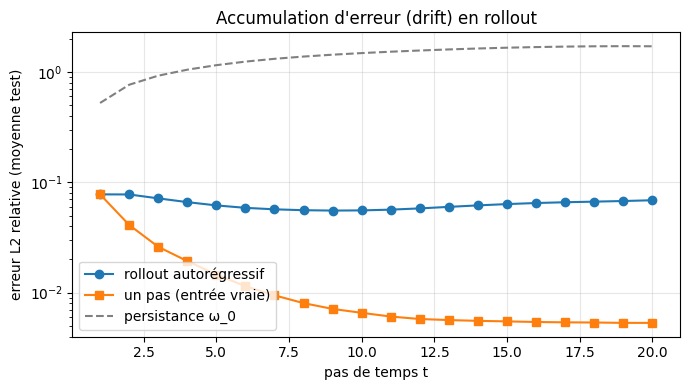

Rollout error t=1, 5, 10, 20: [0.078, 0.062, 0.056, 0.069]
Mean one-step error: 0.0138


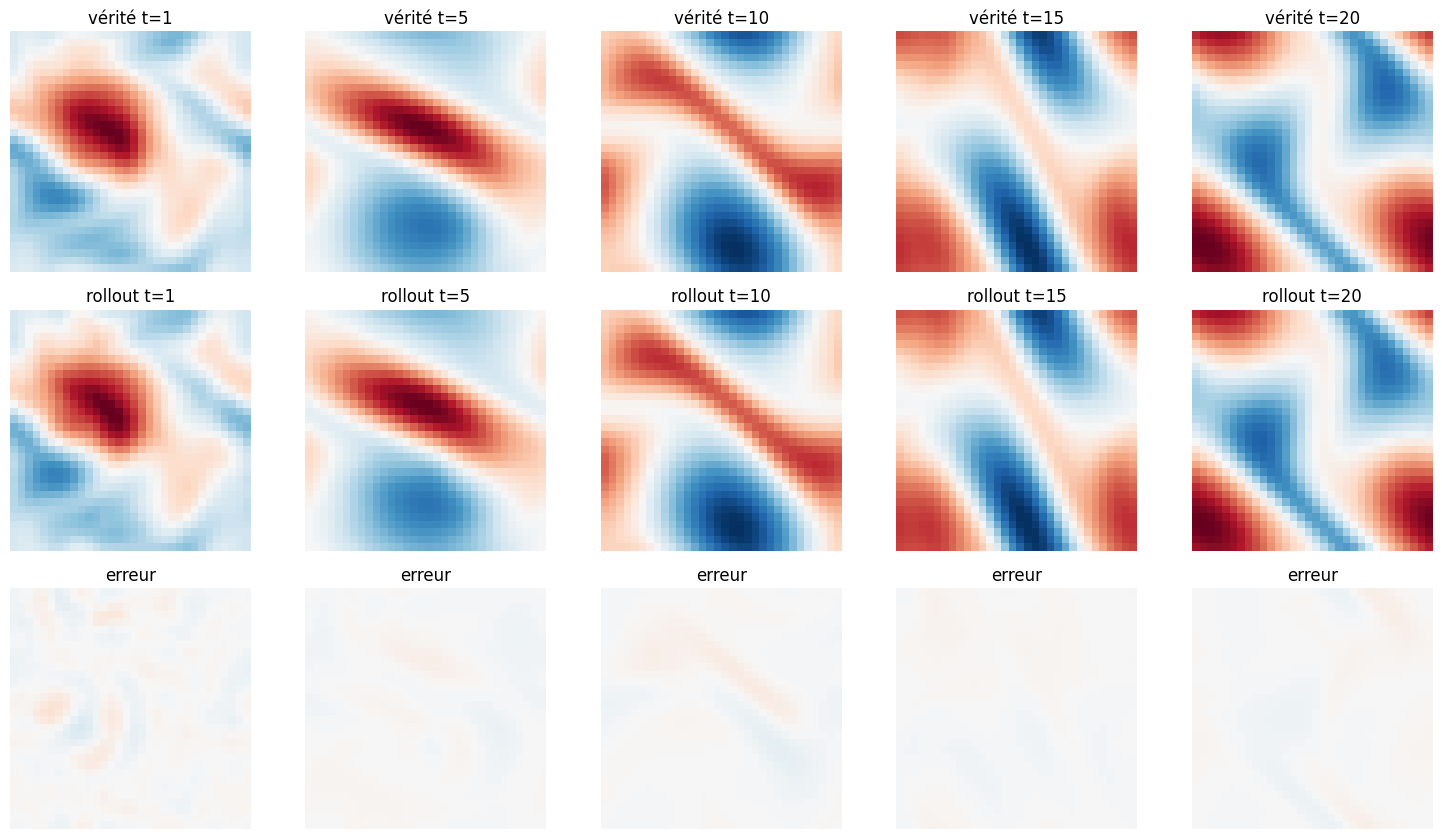

In [24]:
@torch.no_grad()
def rel_l2(a, b):   # per sample
    return (torch.linalg.vector_norm(a - b, dim=(-2, -1)) / torch.linalg.vector_norm(b, dim=(-2, -1))).squeeze(1)

ns_model.eval()
Wt = W_test.to(device).unsqueeze(2)          # (B, T+1, 1, H, W)
T_max = Wt.shape[1] - 1
err_roll, err_one, err_pers = [], [], []
w_hat = Wt[:, 0]
roll_frames = [w_hat.cpu()]
with torch.no_grad():
    for t in range(1, T_max + 1):
        w_hat = w_hat + ns_model(w_hat)                               # autoregressive rollout
        one = Wt[:, t - 1] + ns_model(Wt[:, t - 1])                    # one step from the ground truth
        err_roll.append(rel_l2(w_hat, Wt[:, t]).mean().item())
        err_one.append(rel_l2(one, Wt[:, t]).mean().item())
        err_pers.append(rel_l2(Wt[:, 0], Wt[:, t]).mean().item())
        roll_frames.append(w_hat.cpu())

ts = np.arange(1, T_max + 1)
plt.figure(figsize=(7, 4))
plt.plot(ts, err_roll, "o-", label="autoregressive rollout")
plt.plot(ts, err_one, "s-", label="one step (true input)")
plt.plot(ts, err_pers, "--", c="gray", label="persistence ω_0")
plt.xlabel("time step t"); plt.ylabel("relative L2 error (test mean)")
plt.yscale("log"); plt.grid(alpha=0.3); plt.legend(); plt.title("Error accumulation (drift) during rollout")
plt.tight_layout(); plt.show()
print("Rollout error t=1, 5, 10, 20:", [round(err_roll[t - 1], 3) for t in [1, 5, 10, 20]])
print("Mean one-step error:", round(float(np.mean(err_one)), 4))

show_t = [1, 5, 10, 15, 20]
fig, axs = plt.subplots(3, len(show_t), figsize=(3 * len(show_t), 8.5))
for j, t in enumerate(show_t):
    tru, pr = W_test[0, t], roll_frames[t][0, 0]
    v = tru.abs().max().item()
    axs[0, j].imshow(tru, origin="lower", cmap="RdBu_r", vmin=-v, vmax=v); axs[0, j].set_title(f"truth t={t}")
    axs[1, j].imshow(pr, origin="lower", cmap="RdBu_r", vmin=-v, vmax=v); axs[1, j].set_title(f"rollout t={t}")
    axs[2, j].imshow(pr - tru, origin="lower", cmap="RdBu_r", vmin=-v, vmax=v); axs[2, j].set_title("error")
    for i in range(3): axs[i, j].axis("off")
plt.tight_layout(); plt.show()

### Interpreting the rollout

* **One-step error.** On the test set, it is 0.078 at the first step, then drops to about 0.005. The first transition, which starts from a non-physical Gaussian random field, is the hardest; afterwards the flow approaches a forcing-dominated regime that is easier to predict.
* **Rollout.** The error stays around 0.055 to 0.07: it is first dominated by the first-step error, then **slowly increases from t ≈ 9** (0.055 to 0.069). At t = 20, it is about **13 times** the one-step error: this is error accumulation (drift), as with an RNN, since each prediction is fed back as input although the model was only trained on exact inputs (distribution shift).
* **Persistence.** Predicting $\omega_0$ gives an error of 1.7 at t = 20: the model has clearly learned the dynamics.
* The drift remains moderate here because with $\nu=10^{-3}$ at this scale the flow is only mildly chaotic: diffusion damps part of the error. With $\nu=10^{-4}$ or $10^{-5}$ (turbulent regime) it would grow much faster. The classic remedies are training on several unrolled steps, injecting noise into the inputs, or the "pushforward" trick.